# Verificacion del entorno

Corre todas las celdas (`Run All`). Si llegas al final sin errores, el requisito del curso *"Python 3, Jupyter and NetworkX installed and working"* esta cumplido.

## 1. Python y librerias

In [1]:
import sys, networkx as nx, matplotlib, pandas as pd, numpy as np, scipy

print("Python    ", sys.version.split()[0])
print("networkx  ", nx.__version__)
print("matplotlib", matplotlib.__version__)
print("pandas    ", pd.__version__)
print("numpy     ", np.__version__)
print("scipy     ", scipy.__version__)

Python     3.14.5
networkx   3.6.1
matplotlib 3.11.1
pandas     3.0.5
numpy      2.5.2
scipy      1.18.1


## 2. Un grafo de ejemplo

El *karate club* de Zachary: 34 miembros de un club que se dividio en dos tras un pleito. Es el "hola mundo" del analisis de redes sociales.

In [2]:
G = nx.karate_club_graph()

print("nodos:  ", G.number_of_nodes())
print("aristas:", G.number_of_edges())
print("densidad:", round(nx.density(G), 4))

nodos:   34
aristas: 78
densidad: 0.139


## 3. Metricas basicas

- **camino promedio**: cuantos saltos separan a dos personas cualesquiera
- **clustering**: que tanto los amigos de alguien son amigos entre si
- **centralidad de grado**: quien tiene mas conexiones

In [3]:
print("camino promedio:", round(nx.average_shortest_path_length(G), 3))
print("clustering:     ", round(nx.average_clustering(G), 3))

top = sorted(nx.degree_centrality(G).items(), key=lambda x: -x[1])[:5]
for nodo, val in top:
    print(f"  nodo {nodo:>2}  centralidad {val:.3f}")

camino promedio: 2.408
clustering:      0.571
  nodo 33  centralidad 0.515
  nodo  0  centralidad 0.485
  nodo 32  centralidad 0.364
  nodo  2  centralidad 0.303
  nodo  1  centralidad 0.273


## 4. Deteccion de comunidades

El algoritmo de Louvain agrupa nodos en comunidades densamente conectadas entre si. Sin saber nada del pleito, deberia recuperar la division del club.

In [4]:
comunidades = nx.community.louvain_communities(G, seed=42)

print(f"{len(comunidades)} comunidades encontradas")
for i, c in enumerate(comunidades):
    print(f"  comunidad {i}: {len(c)} miembros -> {sorted(c)}")

4 comunidades encontradas
  comunidad 0: 6 miembros -> [1, 2, 3, 7, 12, 13]
  comunidad 1: 10 miembros -> [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
  comunidad 2: 4 miembros -> [24, 25, 28, 31]
  comunidad 3: 14 miembros -> [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]


## 5. Visualizacion

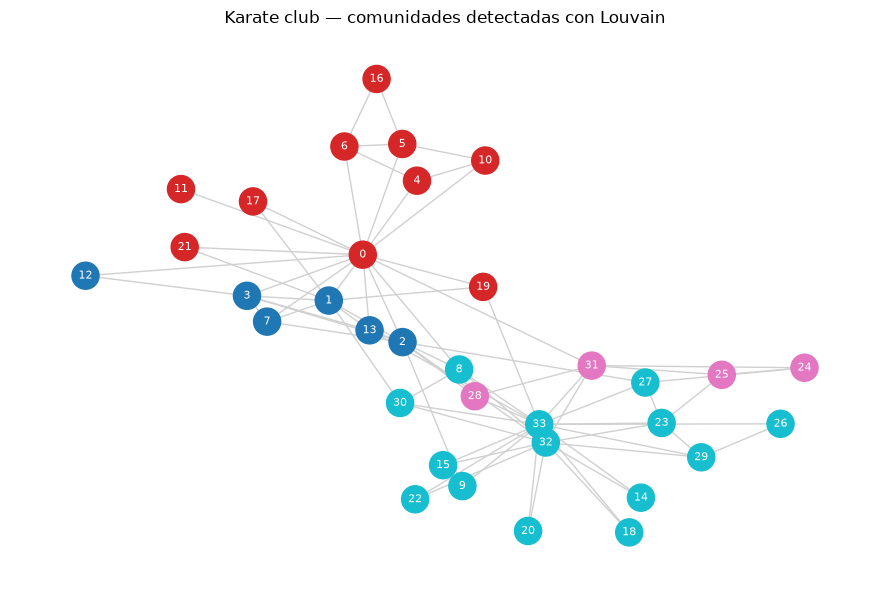

In [5]:
import matplotlib.pyplot as plt

color = {n: i for i, c in enumerate(comunidades) for n in c}
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(9, 6))
nx.draw_networkx(G, pos, ax=ax, node_color=[color[n] for n in G],
                 cmap="tab10", node_size=380, font_size=8,
                 font_color="white", edge_color="#d0d0d0")
ax.set_title("Karate club — comunidades detectadas con Louvain")
ax.axis("off")
plt.tight_layout()
plt.show()

---

**Si todo lo de arriba corrio, tu entorno esta listo.**